# Processing raw SP2b data with PySP2

This tutorial follows a raw Single Particle Soot Photometer (SP2) file through two levels of processing:

1. **Particle-by-particle statistics**: read the waveforms, fit peaks, and calculate calibrated scattering diameters and incandescence/black-carbon masses.
2. **Time-averaged products**: combine the particle statistics with housekeeping flow data to calculate size distributions and mass/number concentrations.

The example files come from the [`arm_test_data`](https://github.com/ARM-DOE/arm-test-data) repository. The `.sp2b`, `.ini`, and `.hk` files are a matched set: the raw waveform file, acquisition/calibration settings, and housekeeping data, respectively.

The particle-level and time-averaged products are stored as separate datasets for analysis.

## Learning objectives

By the end of this tutorial, you will be able to:

- Read raw SP2b waveforms and inspect individual detector channels.
- Fit waveform peaks and apply size and rBC-mass calibrations.
- Combine particle statistics with housekeeping data to calculate concentrations and size distributions.
- Save particle-level and time-averaged products as NetCDF files.

This processing is being done by a package called PySP2. For more information about PySP2, see the following talk this week:

### Presentation details

| Item | Details |
|---|---|
| **Title** | *PySP2: An Open-Source Framework for Single-Particle Soot Photometer Data Processing* |
| **Date** | Wednesday, October 28 |
| **Time** | 10:45 a.m. |
| **Session** | 5IM |
| **Location** | Ballroom C, Pasadena Convention Center |


## About the SP2

![SP2 instrument](https://envea.global/wp-content/uploads/2026/03/SP2-200219-copy.png)

A Single Particle Soot Photometer (SP2) measures individual aerosol particles as they pass through a focused laser beam. The instrument records the time-dependent light signals produced by each particle, rather than only reporting an average concentration.

Two measurements are especially important in this tutorial:

- **Elastic scattering** measures the light scattered by a particle and is used to estimate its physical size after calibration.
- **Laser-induced incandescence (LII)** heats refractory black carbon (rBC) in the laser beam until it glows. The incandescence signal is calibrated to estimate rBC mass.

The raw waveform contains the signals from multiple detector channels for each particle transit. PySP2 reads those waveforms, identifies and fits the scattering and incandescence peaks, applies instrument-specific calibrations, and returns particle-level results as [xarray datasets](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.html). Those particle-level results can then be combined with flow and timing information to calculate time-averaged number, size, and rBC mass concentrations. See the PySP2 [particle-information reference](https://arm-doe.github.io/PySP2/users_guide/particle_information.html) for descriptions of the particle-level variables.

This workflow uses three related files: the `.sp2b` file contains raw particle waveforms, the `.ini` file contains acquisition and calibration settings, and the `.hk` file contains housekeeping and flow measurements. Keeping these files matched is important because the calibration and flow information provide the context needed to interpret the raw signals.

## Prerequisites

Before continuing, you should be familiar with:

- [NumPy basics](../ACT-Python-Tutorial/2a-scientific_libraries_numpy)
- [Xarray basics](../ACT-Python-Tutorial/2c-scientific_libraries_xarray)
- [Matplotlib plotting](../ACT-Python-Tutorial/2c-scientific_libraries_xarray)

The Xarray tutorial includes examples of plotting with Matplotlib.


## AI Disclosure

Codex/GPT 5.6-Luna assisted with generating this notebook.

## Setup

### Installation

Install PySP2 and the ARM test-data package in the environment used for this notebook if needed:

```bash
conda install -c conda-forge pysp2 arm-test-data
```

PySP2 returns [xarray](https://xarray.dev/) datasets, so the intermediate and final data products can be inspected, plotted, and saved using the broader scientific-Python ecosystem. For more information on the xarray Dataset object, see [xr.Dataset](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.html).

### Input files

| File | Contents |
|---|---|
| `.sp2b` | Raw particle waveforms |
| `.ini` | Acquisition and calibration settings |
| `.hk` | Housekeeping and flow measurements |

In [2]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from arm_test_data import DATASETS
import pysp2

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 120

Fetching files from ARM test data repository...
DATASETS: ['201509021500.bi', '20230721121710.ini', '20230721121711.hk', '20230721x001.sp2b', '20230721x002.sp2b', 'AAFNAV_COR_20181104_R0.ict', 'AMF_US-CU1_BASE_HH_1-5.csv', 'AMF_US-CU1_BIF_20250318.xlsx', 'ESRL-GMD-AEROSOL_v1.0_HOUR_MLO_s20200101T000000Z_e20210101T000000Z_c20210214T053835Z.nc', 'NEON.D18.BARR.DP1.00002.001.000.010.001.SAAT_1min.2022-10.expanded.20221107T205629Z.csv', 'NEON.D18.BARR.DP1.00002.001.sensor_positions.20221107T205629Z.csv', 'NEON.D18.BARR.DP1.00002.001.variables.20221201T110553Z.csv', 'US1200R.20200101000000.20210214053818.nephelometer.aerosol_light_scattering_coefficient.pm10.1y.1h.US06L_TSI_3563_MLO.US06L_scat_coef.lev2.nas', 'anltwr_mar19met.data', 'ayp22199.21m', 'ayp22200.00m', 'bnfcsapr2radclss.c2.20250619.000000.nc', 'bnfldquantsM1.c1.20250619.000000.nc', 'bnfldquantsS30.c1.20250619.000000.nc', 'bnfmetM1.b1.20250619.000000.cdf', 'bnfmetS20.b1.20250619.000000.cdf', 'bnfmetS30.b1.20250619.000000.cdf', 'b

## 1. Download an example dataset

The `DATASETS` structure contains example raw SP2 data for a 10-minute period that we can process with PySP2. `DATASETS.fetch` downloads a file into the local `arm_test_data` cache the first time it is requested and returns its local path on subsequent calls. For a real deployment, replace these three names with the matching files from that deployment. See the PySP2 [raw-file processing guide](https://arm-doe.github.io/PySP2/users_guide/processing_raw_file.html) for more information about reading SP2b files.

In [5]:
sp2b_file = DATASETS.fetch(
    "mosaossp2M1.00.20191216.130601.raw.20191216x193.sp2b"
)
ini_file = DATASETS.fetch(
    "mosaossp2M1.00.20191216.000601.raw.20191216000000.ini"
)
hk_file = DATASETS.fetch(
    "mosaossp2auxM1.00.20191217.010801.raw.20191216000000.hk"
)

for label, filename in {"SP2b": sp2b_file, "INI": ini_file, "HK": hk_file}.items():
    print(f"{label}: {filename}")

SP2b: /Users/rjackson/Library/Caches/arm-test-data/mosaossp2M1.00.20191216.130601.raw.20191216x193.sp2b
INI: /Users/rjackson/Library/Caches/arm-test-data/mosaossp2M1.00.20191216.000601.raw.20191216000000.ini
HK: /Users/rjackson/Library/Caches/arm-test-data/mosaossp2auxM1.00.20191217.010801.raw.20191216000000.hk


## 2. Read the raw SP2b waveforms

### Read waveform data

PySP2 supports the standard raw format supplied by Envea instruments. First, we read the raw waveforms from the `.sp2b` file. [`read_sp2`](https://arm-doe.github.io/PySP2/developers_guide/generated/pysp2.io.read_sp2.html) decodes these binary records into one xarray dataset.

Each `event_index` is a particle trigger; `Data_ch0` through `Data_ch7` contain the digitized detector waveforms, and `columns` is the number of bins in each waveform, typically 100. Each bin represents a waveform sample. As the particle moves through the SP2 sample volume, it scatters the laser beam. If it contains rBC, it also incandesces in the laser beam.

For an 8-channel SP2, `ch0` is a high-gain scattering detector while `ch4` is a low-gain detector. Using detectors with different gains allows particles across a wider size range to be detected and sized. The low-gain detector is designed for signals that saturate the high-gain detector, allowing detection and sizing of larger particles (approximately >0.2 µm). The high-gain detector is designed for the smaller rBC-containing particles detected by the SP2.

`ch1` is designed for high gain incandescence signals, while ch5 is for low gain signals. 
At this stage the signals are instrument counts, not yet particle size or mass.

In [6]:
raw = pysp2.io.read_sp2(sp2b_file)
print(raw)
print(f"\nParticle records: {raw.sizes['event_index']:,}")

<xarray.Dataset> Size: 38MB
Dimensions:          (event_index: 5877, columns: 100)
Dimensions without coordinates: event_index, columns
Data variables: (12/19)
    time             (event_index) datetime64[ns] 47kB 2019-12-16T12:42:50.67...
    Flag             (event_index) int16 12kB 16 16 23 16 16 ... 2073 16 16 2329
    Res1             (event_index) float32 24kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    Res5             (event_index) float32 24kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    Res6             (event_index) float32 24kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
    Res7             (event_index) float64 47kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    ...               ...
    Data_ch2         (event_index, columns) int64 5MB -29892 -29896 ... -29884
    Data_ch3         (event_index, columns) int64 5MB -84 -168 ... 32764 32764
    Data_ch4         (event_index, columns) int64 5MB -30144 -30144 ... -30152
    Data_ch5         (event_index, columns) int64 5MB -29900 -29908 ... -29896
    Data_ch6    

### Inspect high-gain channels

The plot below shows the scattering and incandescence waveforms for one particle. These values are `int16` quantizations of a voltage and do not have physical units. The baseline scattering signal is encoded near -29,000, so this particle's signal is about 4,000 quantizations tall. The Gaussian-shaped peak indicates a scattering signal.

The noisy `ch1` waveform indicates no detectable incandescence signal. This particle therefore likely contains no rBC within the detection limits of the SP2.

*Figure: High-gain scattering (`ch0`) and incandescence (`ch1`) waveforms for one particle. The y-axis is instrument counts, not a calibrated physical unit.*

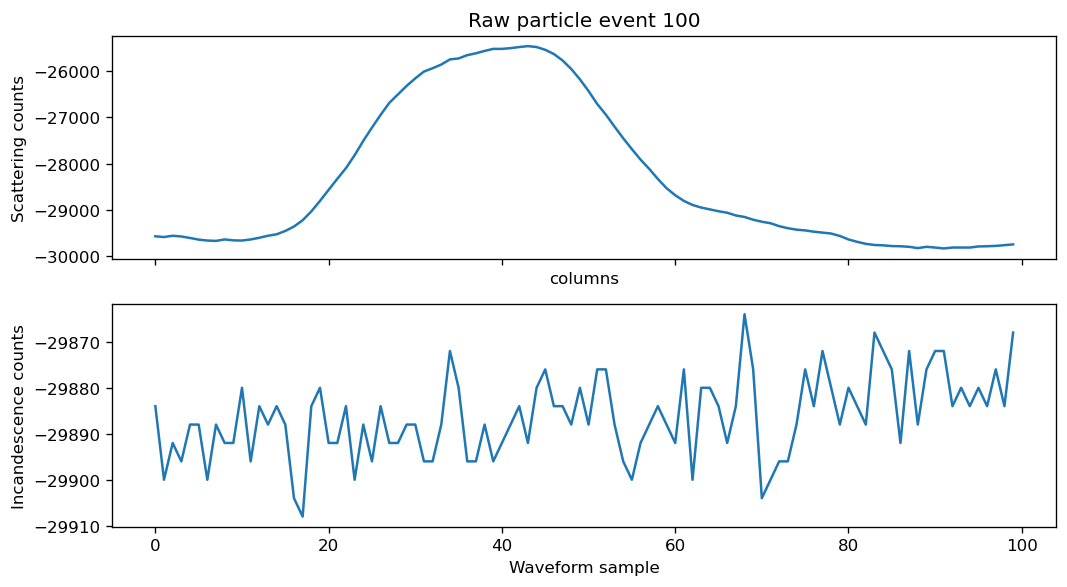

In [7]:
# High-gain scattering and incandescence waveforms.
event = 100
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
raw.Data_ch0.isel(event_index=event).plot(ax=axes[0])
raw.Data_ch1.isel(event_index=event).plot(ax=axes[1])
axes[0].set_title(f"Raw particle event {event}")
axes[0].set_ylabel("Scattering counts")
axes[1].set_ylabel("Incandescence counts")
axes[1].set_xlabel("Waveform sample")
plt.tight_layout()

### Inspect low-gain channels

The low-gain `ch4` peak is about 400 quantizations tall, indicating lower sensitivity to the same particle-scattering signal. The noisy `ch5` waveform again suggests that this particle has no detectable rBC mass.

*Figure: Low-gain scattering (`ch4`) and incandescence (`ch5`) waveforms for the same particle. The y-axis is instrument counts, not a calibrated physical unit.*

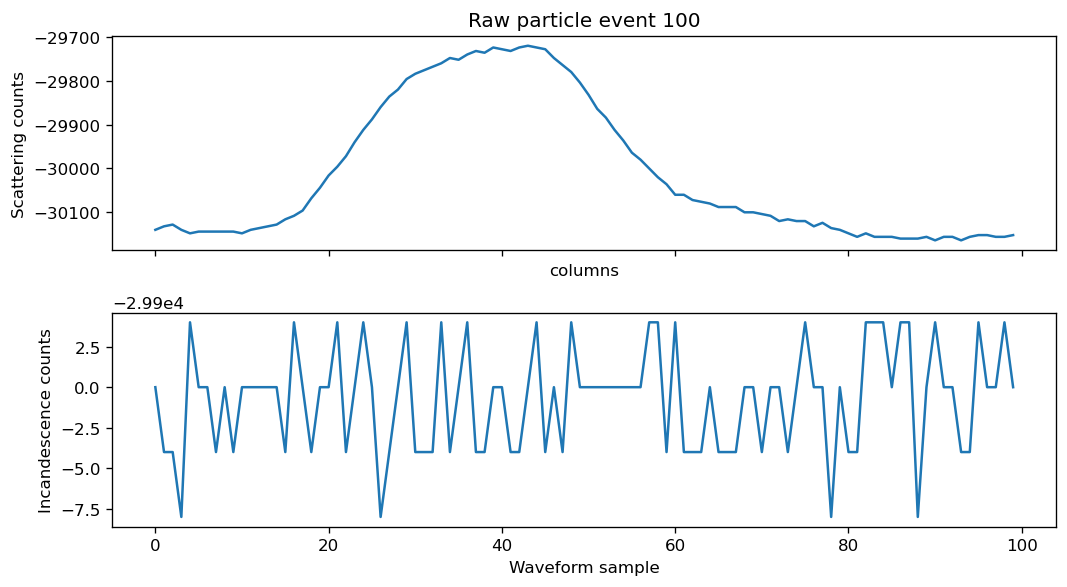

In [8]:
# Low-gain scattering and incandescence waveforms.
event = 100
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(9, 5))
raw.Data_ch4.isel(event_index=event).plot(ax=axes[0])
raw.Data_ch5.isel(event_index=event).plot(ax=axes[1])
axes[0].set_title(f"Raw particle event {event}")
axes[0].set_ylabel("Scattering counts")
axes[1].set_ylabel("Incandescence counts")
axes[1].set_xlabel("Waveform sample")
plt.tight_layout()

## 3. Fit peaks to calculate particle statistics

### Fit waveform peaks

The next step is to load the PySP2 acquisition settings needed for processing. The `.ini` file supplies settings such as the pre-trigger length and the number of particles sampled.

[`gaussian_fit`](https://arm-doe.github.io/PySP2/developers_guide/generated/pysp2.util.gaussian_fit.html) fits the scattering and incandescence signals for every event and adds peak heights, positions, widths, and related diagnostics. These particle statistics are then used to calculate the particle diameters and masses. The [particle-information reference](https://arm-doe.github.io/PySP2/users_guide/particle_information.html) documents the peak and fitted-particle variables.

For this tutorial we use serial processing, as there are only 5887 waveforms in this dataset. SP2 datasets can sometimes contain millions of waveforms per day, especially during polluted conditions. For a large deployment, `parallel="multiprocessing"` or `parallel="dask"` can reduce processing time.

In [9]:
config = pysp2.io.read_config(ini_file)
print(config.sections())
print("1 of every =", config["Acquisition"]["1 of Every"])

fitted = pysp2.util.gaussian_fit(raw, config, parallel=False)
print(fitted[["PkHt_ch0", "PkPos_ch0", "PkHt_ch1", "PkPos_ch1"]])

['Versions', 'Program', 'Controllers', 'Alarms', 'Alicat Flow Controller', 'Control', 'SPAT', 'Acquisition', 'Digital', 'Laser', 'Analog Input', 'Housekeeping', 'Streaming Data', 'Flow Meters', 'Calculated Channels', 'Calculations', 'Missing Value']
1 of every = 1
Processing record 0


/Users/rjackson/PySP2/pysp2/util/peak_fit.py:391: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(_gaus, bins_fit, data_fit, p0=p0, method='lm', maxfev=40, ftol=1e-3)
/Users/rjackson/PySP2/pysp2/util/peak_fit.py:571: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(_gaus, bins_fit, temp1_fit, p0=p0, method='lm', maxfev=50, ftol=1e-3)


Processing record 1000
Processing record 2000
Processing record 3000
Processing record 4000
Processing record 5000
5877 records processed in 3.068802833557129 s
<xarray.Dataset> Size: 188kB
Dimensions:    (event_index: 5877)
Dimensions without coordinates: event_index
Data variables:
    PkHt_ch0   (event_index) float64 47kB 3.3e+03 2.877e+03 ... nan nan
    PkPos_ch0  (event_index) float64 47kB 38.0 72.0 34.0 43.0 ... 39.0 nan nan
    PkHt_ch1   (event_index) float64 47kB 31.6 19.6 6.266e+04 ... 16.0 14.4 25.6
    PkPos_ch1  (event_index) float64 47kB 59.0 84.0 36.0 13.0 ... 2.0 12.0 54.0


### Apply size and mass calibrations

The next step is to convert these particle statistics into particle masses and sizes for analysis. [`calc_diams_masses`](https://arm-doe.github.io/PySP2/developers_guide/generated/pysp2.util.calc_diams_masses.html) converts fitted peak statistics into particle properties, including scattering diameter, black-carbon/soot mass, and acceptance flags. The returned variables are still particle-by-particle: one value per `event_index`. See the [particle-information reference](https://arm-doe.github.io/PySP2/users_guide/particle_information.html) for the names and meanings of these variables.

### How the calibration is applied

The Gaussian fits provide peak heights for the scattering channels (`PkHt_ch0`/`PkHt_ch4`) and the incandescence channels (`PkHt_ch1`/`PkHt_ch5`). Calibration converts those instrument-count measurements into physical particle properties:

1. **Scattering diameter:** calibration particles with known diameters, commonly PSL spheres, establish the detector response. PySP2 applies the instrument's scattering calibration function to the fitted scattering peak height, conceptually
   
   `scattering diameter = f_scattering(scattering peak height)`.
   
   The fitted function and its coefficients are instrument-specific; they may be represented as a log-log polynomial or another empirical response curve. The result is stored in variables such as `ScatDiaBC50` and is reported in nanometers.

2. **rBC mass from incandescence:** the incandescence response is calibrated with particles or standards of known refractory-black-carbon mass. After baseline correction, the fitted incandescence peak is passed through the mass-response calibration, conceptually
   
   `rBC mass = f_incandescence(incandescence peak height)`.
   
   For a linear calibration this is equivalent to `rBC mass = slope × peak height + intercept`; the actual response and channel selection are instrument-specific. PySP2 stores the resulting particle mass in variables such as `incandMass` or related incandescence-mass fields.

3. **Soot diameter:** the calibrated rBC mass can be expressed as a volume-equivalent soot diameter by assuming a particle density, typically using
   
   `soot diameter = (6 × rBC mass / (π × soot density))**(1/3)`.
   
   This is why `sootDiam` and the scattering diameter answer different questions: one is based on incandescence-derived rBC mass, while the other is based on elastic-scattering response. A scattering-based mass product, when calculated, is a mass-equivalent estimate derived from scattering diameter and density assumptions rather than a direct mass measurement.

| Quantity | Calibration input | Result |
|---|---|---|
| Scattering diameter | Scattering peak height and known-size calibration particles | Optical/equivalent particle diameter |
| rBC mass | Incandescence peak height and known-mass calibration | Refractory black-carbon mass |
| Soot diameter | rBC mass and assumed soot density | Volume-equivalent rBC diameter |

> **Calibration note:** if no `DMTGlobals` object is supplied, PySP2 uses its default calibration values. Those defaults are useful for this test dataset and for demonstrating the workflow, but scientific analysis should use the coefficients and rejection limits for the specific SP2 and calibration material.

In [21]:
particle = pysp2.util.calc_diams_masses(fitted)

Number of scattering particles accepted = 4799
Number of scattering particles rejected for min. peak height = 11
Number of scattering particles rejected for peak width = 16
Number of scattering particles rejected for fat peak = 0
Number of scattering particles rejected for peak pos. = 91
Number of incandescence particles accepted = 599
Number of incandescence particles rejected for min. peak height = 6
Number of incandescence particles rejected for peak width = 4221


### Inspect calibrated particle properties

The plot below shows calibrated diameters for the first 1,000 particles. The separation between scattering diameter and soot diameter illustrates that many particles in this example contain little or no detectable rBC.

Text(0.5, 0, 'Particle #')

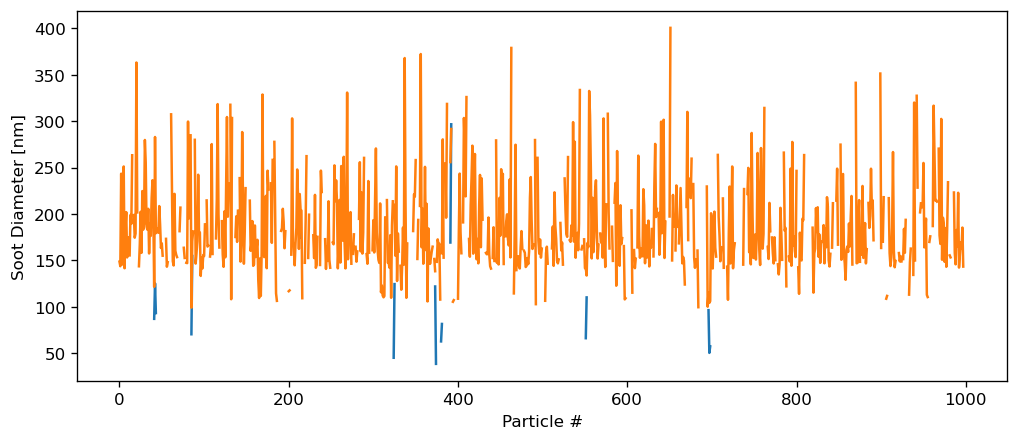

In [22]:
# Inspect the particle-level relationship between incandescence mass and size.
particle["sootDiam"].isel(index=slice(0, 1000)).plot(label="Soot diameter [nm]")
particle["ScatDiaBC50"].isel(index=slice(0, 1000)).plot(label="Scattering diameter [nm]")
plt.ylabel("Diameter [nm]")
plt.xlabel("Particle number")
plt.title("Calibrated particle diameters")
plt.legend()

## 4. Read housekeeping data and process distributions

### Calculate time-averaged products

The final processing step calculates particle size distributions from the scattering and incandescence channels. The size-distribution and concentration calculations need sample flow, duty cycle, pressure, and temperature from the housekeeping file. [`process_psds`](https://arm-doe.github.io/PySP2/developers_guide/generated/pysp2.util.process_psds.html) bins the accepted particle properties and converts counts and mass to concentrations using the measured flow. The [housekeeping-data guide](https://arm-doe.github.io/PySP2/users_guide/view_hk_data.html) describes the input variables, while the [time-series processing guide](https://arm-doe.github.io/PySP2/users_guide/processing_time_series.html) documents the resulting products. The defaults below create 199 bins at 0.005 µm spacing and 10-second averages.

In [24]:
hk = pysp2.io.read_hk_file(hk_file)
print(hk)

psd = pysp2.util.process_psds(
    particle, hk, config,
    deltaSize=0.005,
    num_bins=199,
    avg_interval=10,
)
print(psd)

<xarray.Dataset> Size: 32MB
Dimensions:                    (time: 86400)
Coordinates:
  * time                       (time) datetime64[ns] 691kB 2019-12-16T00:00:0...
Data variables: (12/46)
    Time                       (time) float64 691kB 0.609 1.622 ... 8.64e+04
    Sample Flow LFE            (time) float64 691kB 119.7 120.3 ... 119.2 121.0
    YAG Power                  (time) float64 691kB 5.15 5.279 ... 5.166 5.214
    Incand. Conc.              (time) float64 691kB 6.449 4.512 ... 7.94 10.06
    Sheath Flow Read           (time) float64 691kB 1.006e+03 ... 1e+03
    YAG Crystal Temp           (time) float64 691kB 28.59 28.66 ... 28.69 28.52
    ...                         ...
    Num of Particles           (time) int64 691kB 73 56 53 56 ... 203 241 214
    Num Written to File        (time) int64 691kB 73 56 53 56 ... 203 241 214
    Num in File                (time) int64 691kB 40 96 149 ... 23408 23622
    Laser Power Switch         (time) int64 691kB 1 1 1 1 1 1 1 ... 1 1 1 

### Plot concentration time series

The following plot shows number concentration and incandescence mass concentration. Both values are reported per unit air volume.

<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/f7/j8d4tzw924s73dlkdx4d4h_c0000gp/T/ipykernel_36141/3458399664.py:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axes[1].set_ylabel("Incandescence mass [$\mu g$]")


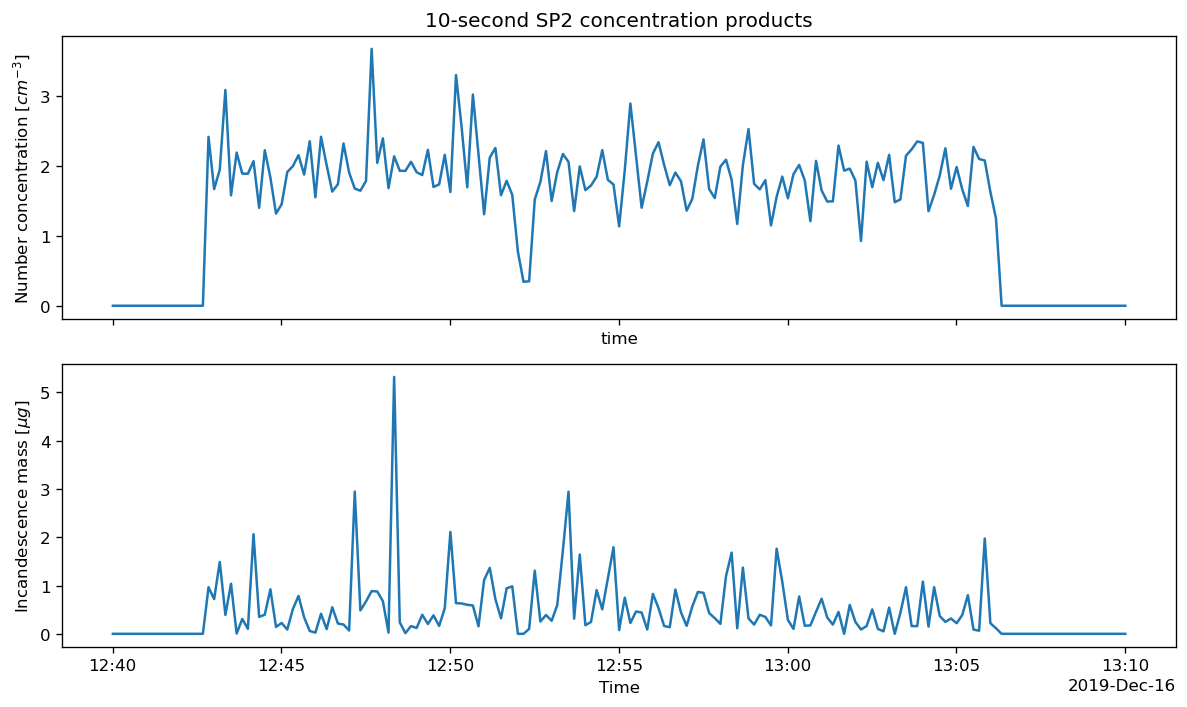

In [31]:
# Time series of integrated number and mass concentration.
time_window = dict(time=slice("2019-12-16T12:40:00", "2019-12-16T13:10:00"))
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 6))
psd["NumConcTotal"].sel(**time_window).plot(ax=axes[0])
psd["MassIncand2total"].sel(**time_window).plot(ax=axes[1])
axes[0].set_ylabel("Number concentration [cm$^{-3}$]")
axes[0].set_title("10-second SP2 concentration products")
axes[1].set_ylabel("Incandescence mass [\\mu g m$^{-3}$]")
axes[1].set_xlabel("Time")
plt.tight_layout()

### Plot size distributions

The following heat maps show scattering number and incandescence mass distributions. The logarithm is used to display values spanning several orders of magnitude; zero and missing values should be handled before applying `np.log10` in production analyses.

<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/var/folders/f7/j8d4tzw924s73dlkdx4d4h_c0000gp/T/ipykernel_36141/820167821.py:8: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  cbar_kwargs=dict(label="$log_{10}$ Incandescence mass\n [$\mu g$ $m^{-3}$ per bin]"))


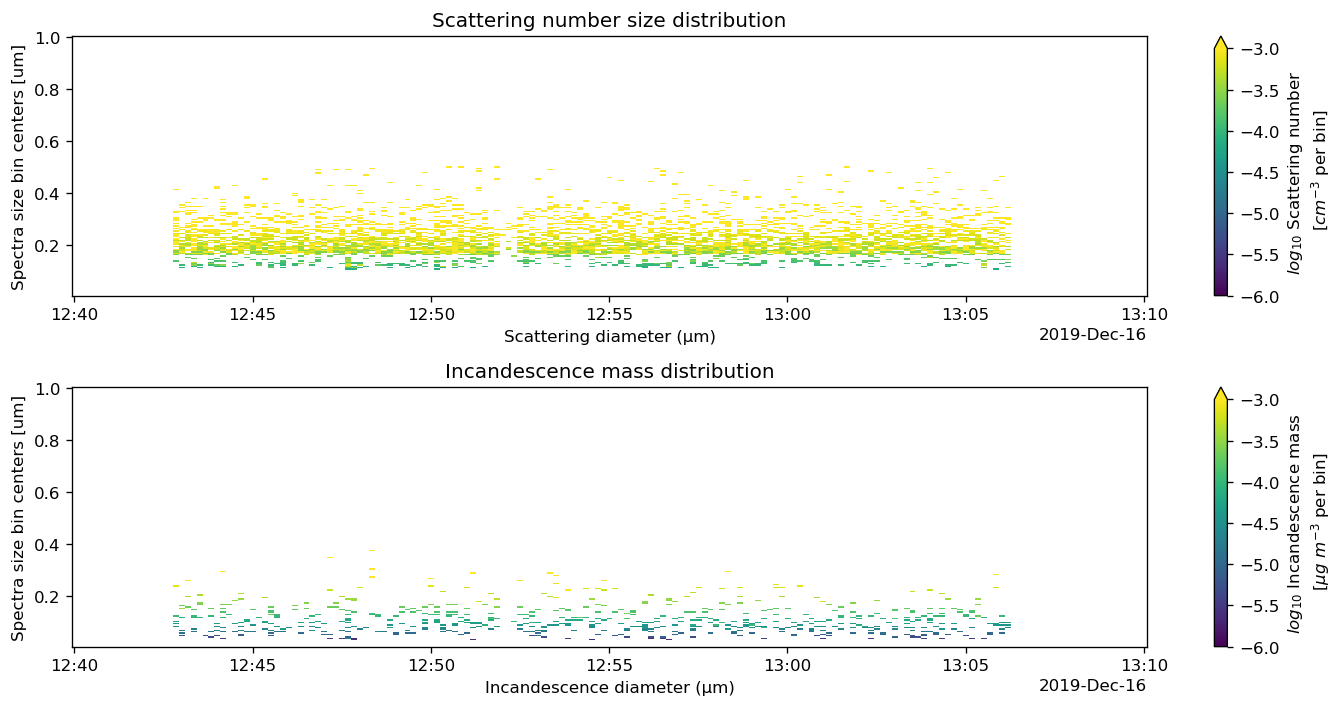

In [34]:
# Plot the scattering number size distribution and incandescence mass distribution.
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
np.log10(psd["ScatMassEnsemble"]).sel(**time_window).plot(
    ax=axes[0], x="time", vmin=-6, vmax=-3,
    cbar_kwargs=dict(label="$log_{10}$ scattering number\n [cm$^{-3}$ per bin]"))
np.log10(psd["IncanMassEnsemble"]).sel(**time_window).plot(
    ax=axes[1], x="time", vmin=-6, vmax=-3, 
    cbar_kwargs=dict(label="$log_{10}$ incandescence mass\n [\\mu g m$^{-3}$ per bin]"))
axes[0].set(title="Scattering number size distribution",
            xlabel="Scattering diameter (µm)")
axes[1].set(title="Incandescence mass distribution",
            xlabel="Incandescence diameter (µm)")
plt.tight_layout()

### Plot mean mass distributions

The mean mass distributions summarize the selected time window and show that these particles have a relatively small rBC mass fraction.

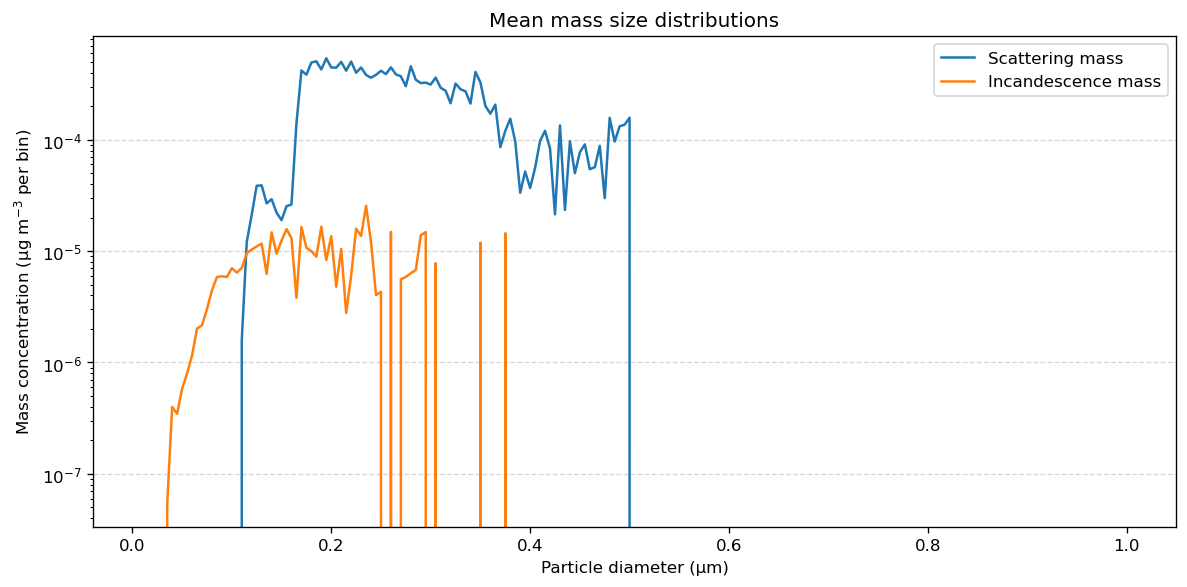

In [39]:
# Mean scattering and incandescence mass size distributions.
mean_scat_mass = psd["ScatMassEnsemble"].sel(**time_window).mean(dim="time")
mean_incan_mass = psd["IncanMassEnsemble"].sel(**time_window).mean(dim="time")

fig, ax = plt.subplots(figsize=(10, 5))
mean_scat_mass.plot(ax=ax, x="num_bins", label="Scattering mass")
mean_incan_mass.plot(ax=ax, x="num_bins", label="Incandescence mass")
ax.set(
    title="Mean mass size distributions",
    xlabel="Particle diameter (µm)",
    ylabel="Mass concentration (µg m$^{-3}$ per bin)",
)
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend()
ax.set_yscale('log')
plt.tight_layout()

## 5. Save the processed products

NetCDF preserves the xarray dimensions, coordinates, variable attributes, and processing metadata. Saving both stages is useful: the particle-level file lets you revisit filtering/calibration, while the PSD file is convenient for analysis and visualization.

In [41]:
output_dir = Path("pysp2_outputs")
output_dir.mkdir(exist_ok=True)
# PySP2 assigns NaN as a fill value to some integer flag variables.
# Remove that invalid fill value so NetCDF can preserve the integer data.
for name, variable in particle.variables.items():
    if np.issubdtype(variable.dtype, np.integer):
        variable.attrs.pop("_FillValue", None)
        variable.encoding.pop("_FillValue", None)

particle.to_netcdf(output_dir / "particle_statistics.nc")
psd.to_netcdf(output_dir / "sp2_size_distributions.nc")
print(f"Wrote processed products to {output_dir.resolve()}")

Wrote processed products to /Users/rjackson/ARM-Notebooks/Tutorials/AAAR-2026-ACT-Tutorial/pysp2_outputs


### Outputs

This notebook writes the following files to `pysp2_outputs/`:

- `particle_statistics.nc`: particle-level fitted and calibrated properties.
- `sp2_size_distributions.nc`: time-averaged concentrations and size distributions.

### Summary

The core PySP2 workflow is:

```python
raw = pysp2.io.read_sp2(sp2b_file)
fitted = pysp2.util.gaussian_fit(raw, config)
particle = pysp2.util.calc_diams_masses(fitted)
psd = pysp2.util.process_psds(particle, hk, config)
```

For production processing, confirm the instrument-specific `.ini`/`.hk` pairing, calibration coefficients, inlet/sample-flow assumptions, rejection limits, and averaging interval before interpreting the resulting concentrations.

### Future features

Mixing-state analysis is currently a work in progress. Support for the normalized derivative method, which can size particles that partially evaporate inside the SP2 sample volume, is planned.